In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys
sys.path.append('../..')
sys.path.append('../../results')

from utils import W_from_J, init_cond, J_dynamics, solve_rk4_springBox, f
from fig1.fig1_functions import (
    compute_amplification_grid,
    plot_phase_portrait,
    make_figures_color_from_ampl
)

In [8]:
# Load pre-computed high-amplification matrices.
# Download from Zenodo [DOI] and place at data/fig1/high_ampl_matrices_2x2.pickle
with open('../../data/fig1/high_ampl_matrices_2x2.pickle', 'rb') as file:
    matrices = pickle.load(file)

In [9]:
# --- Simulation parameters ---
T    = 100
dt   = 0.1
tauE = 1
tauI = 1

N = 2
a = 1 * np.ones(N)
b = 1 * np.ones(N)
c = 2 * np.ones(N)
bias = np.zeros(N)

# Select matrix and compute W, initial conditions
J = matrices[9057]
W, _ = W_from_J(J, a, b, c)
init_conditions = init_cond(J)

x0_ampl    = 0.01 * init_conditions[:, 0]
x0_nonampl = 0.8  * init_conditions[:, 1] * (-1)

t, r_nonlinear_ampl    = solve_rk4_springBox(x0_ampl,    W, tauE, tauI, T, dt, a, b, c, bias)
t, r_nonlinear_nonampl = solve_rk4_springBox(x0_nonampl, W, tauE, tauI, T, dt, a, b, c, bias)

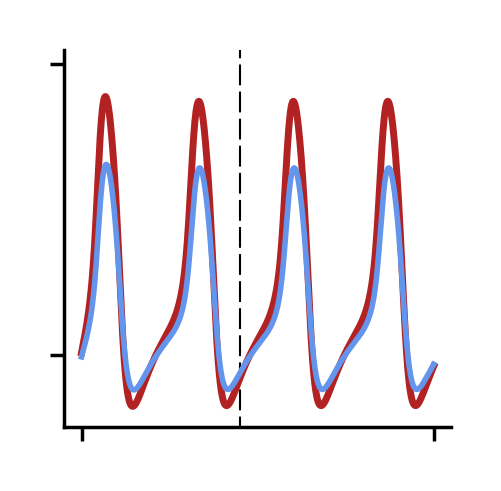

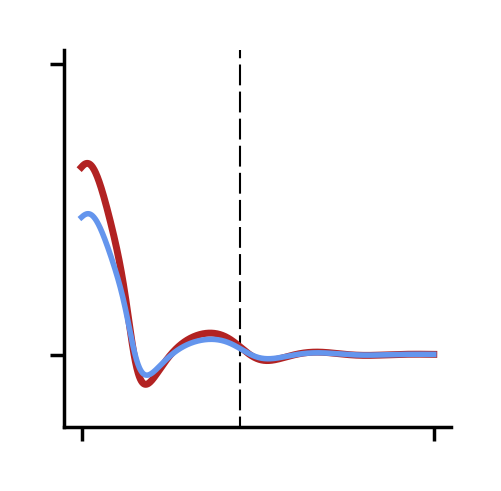

In [10]:
# --- Trajectory plots: amplifying initial condition ---
fig, ax = plt.subplots(figsize=(1, 1), dpi=500)
ax.axvline(x=45, color='k', linewidth=0.3, linestyle=(5, (10, 3)))
ax.plot(t, r_nonlinear_ampl[:, 0], color='firebrick',      linewidth=1,   label='E')
ax.plot(t, r_nonlinear_ampl[:, 1], color='cornflowerblue', linewidth=0.8, label='I')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(width=0.5, pad=1, length=2)
ax.set_xticks([0, 100]); ax.set_xticklabels(['', ''])
ax.set_yticks([0, 1]);   ax.set_yticklabels(['', ''])
ax.set_ylim(-0.25, 1.05)
plt.show()

# --- Trajectory plots: non-amplifying initial condition ---
fig, ax = plt.subplots(figsize=(1, 1), dpi=500)
ax.axvline(x=45, color='k', linewidth=0.3, linestyle=(5, (10, 3)))
ax.plot(t, r_nonlinear_nonampl[:, 0], color='firebrick',      linewidth=1,   label='E')
ax.plot(t, r_nonlinear_nonampl[:, 1], color='cornflowerblue', linewidth=0.8, label='I')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.tick_params(width=0.5, pad=1, length=2)
ax.set_xticks([0, 100]); ax.set_xticklabels(['', ''])
ax.set_yticks([0, 1]);   ax.set_yticklabels(['', ''])
ax.set_ylim(-0.25, 1.05)
plt.show()

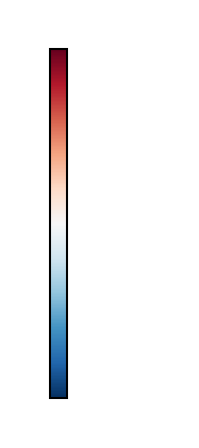

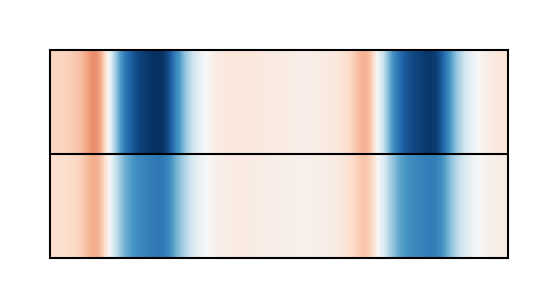

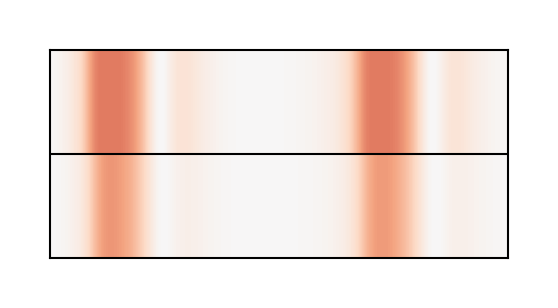

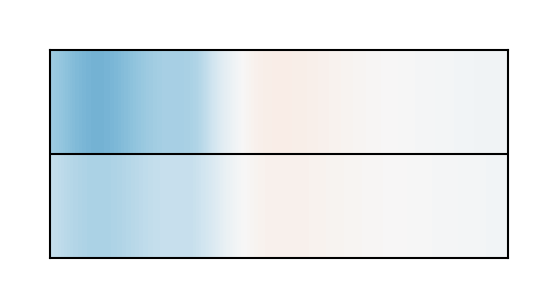

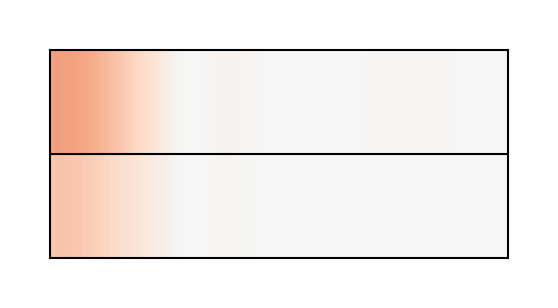

In [11]:
# --- Linear / nonlinear decomposition heatmaps ---
make_figures_color_from_ampl(
    r_nonlinear_ampl=r_nonlinear_ampl,
    r_nonlinear_nonampl=r_nonlinear_nonampl,
    W=W, a=a[0], b=b[0], c=c[0], t=t,
    i0=0, i1=450,
    figsize=(1, 0.5), dpi=500, border_lw=0.3,
    cmap='RdBu_r',
    separator_y=N/2, separator_lw=0.3, separator_color='black'
)

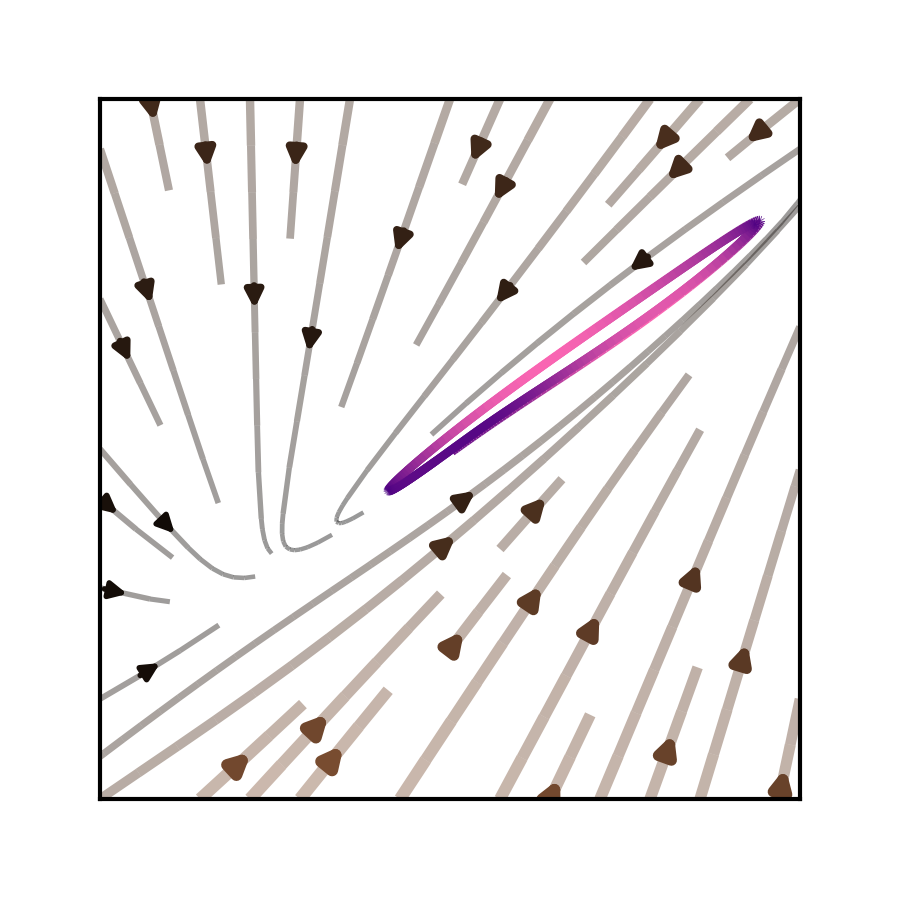

In [12]:
# --- Phase portrait: nonlinear vector field + trajectory overlay ---
plot_phase_portrait(
    W=W, a=a, b=b, c=c,
    r_traj=r_nonlinear_ampl,
    xlim=(-1., 1.), ylim=(-1., 1.),
    density=0.5,
    mask_radius=0.03,
    seeds=np.array([[0.1, -0.1]]),
    figsize=(1, 1), dpi=1000
)
plt.show()

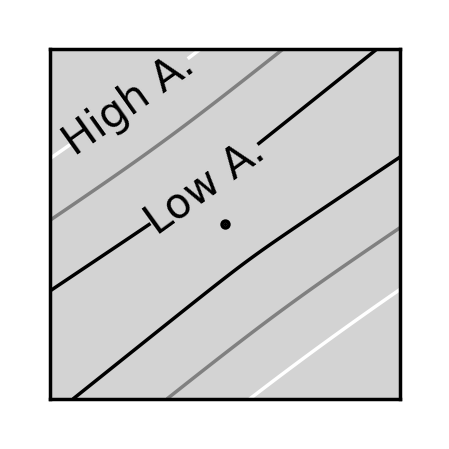

In [13]:
# --- Amplification landscape on a grid of initial conditions ---
X, Y, F = compute_amplification_grid(J, n=500, xlim=(-0.1, 0.1), ylim=(-0.1, 0.1))

levels = [0.5, 1.2, 1.8]

fig, ax = plt.subplots(figsize=(1, 1), dpi=500)
CS = ax.contour(X, Y, F, levels=levels,
                colors=['k', 'grey', 'white'], linewidths=0.5, linestyles='solid')
ax.clabel(CS,
          manual=[(-0.01, 0.02), (-0.055, 0.07)],
          inline=True, fontsize=6,
          fmt={0.5: 'Low A.', 1.8: 'High A.'},
          colors='k')
ax.plot(0, 0, 'ko', ms=0.5)
ax.set_facecolor('lightgrey')
ax.set_aspect('equal', 'box')
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_linewidth(0.5)
plt.tight_layout()
plt.show()